# Analiza meczów StatsBomb

Notebook do eksploracji i analizy danych z meczów

In [1]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)

import sys
from pathlib import Path
project_root = Path().resolve().parent.parent
sys.path.insert(0, str(project_root))

from src.data.data_loader import load_statsbomb_socceraction_data

pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## Wczytanie danych

In [2]:
matches = list(load_statsbomb_socceraction_data("../../data/statsbomb/data", 55, 282))

Found 51 matches in competition 55, season 282
Loading events for match 3942819 (1/51)...
Loading events for match 3943043 (2/51)...
Loading events for match 3942752 (3/51)...
Loading events for match 3942382 (4/51)...
Loading events for match 3942349 (5/51)...
Loading events for match 3930180 (6/51)...
Loading events for match 3930171 (7/51)...
Loading events for match 3942227 (8/51)...
Loading events for match 3942226 (9/51)...
Loading events for match 3938645 (10/51)...
Loading events for match 3930184 (11/51)...
Loading events for match 3941022 (12/51)...
Loading events for match 3941021 (13/51)...
Loading events for match 3941020 (14/51)...
Loading events for match 3941019 (15/51)...
Loading events for match 3941018 (16/51)...
Loading events for match 3941017 (17/51)...
Loading events for match 3930182 (18/51)...
Loading events for match 3930179 (19/51)...
Loading events for match 3940983 (20/51)...
Loading events for match 3940878 (21/51)...
Loading events for match 3930177 (22/5

## Podstawowe informacje

In [3]:
# Wyświetl informacje o pierwszym meczu
game, events = matches[0]
print("Przykładowy mecz:")
print(game)
print(f"\nLiczba zdarzeń: {len(events)}")
print(f"\nKolumny zdarzeń: {events.columns.tolist()}")

Przykładowy mecz:
game_id                          3942819
season_id                            282
competition_id                        55
competition_stage            Semi-finals
game_day                               6
game_date            2024-07-10 22:00:00
home_team_id                         941
away_team_id                         768
home_score                             1
away_score                             2
venue                  Signal-Iduna-Park
referee                     Felix Zwayer
home_team_name               Netherlands
away_team_name                   England
Name: 0, dtype: object

Liczba zdarzeń: 3485

Kolumny zdarzeń: ['game_id', 'event_id', 'period_id', 'team_id', 'player_id', 'type_id', 'type_name', 'index', 'timestamp', 'minute', 'second', 'possession', 'possession_team_id', 'possession_team_name', 'play_pattern_id', 'play_pattern_name', 'team_name', 'duration', 'extra', 'related_events', 'player_name', 'position_id', 'position_name', 'location', 'under_

## Analiza strzałów

In [4]:
len(matches)

51

In [5]:
for game, events in matches:
    print(f"Mecz {game['game_id']},  {game['competition_stage']}: {len(events)} zdarzeń")

Mecz 3942819,  Semi-finals: 3485 zdarzeń
Mecz 3943043,  Final: 3312 zdarzeń
Mecz 3942752,  Semi-finals: 3328 zdarzeń
Mecz 3942382,  Quarter-finals: 3415 zdarzeń
Mecz 3942349,  Quarter-finals: 5190 zdarzeń
Mecz 3930180,  Group Stage: 3198 zdarzeń
Mecz 3930171,  Group Stage: 3881 zdarzeń
Mecz 3942227,  Quarter-finals: 4882 zdarzeń
Mecz 3942226,  Quarter-finals: 4463 zdarzeń
Mecz 3938645,  Group Stage: 3525 zdarzeń
Mecz 3930184,  Group Stage: 2953 zdarzeń
Mecz 3941022,  Round of 16: 3722 zdarzeń
Mecz 3941021,  Round of 16: 2996 zdarzeń
Mecz 3941020,  Round of 16: 4221 zdarzeń
Mecz 3941019,  Round of 16: 3941 zdarzeń
Mecz 3941018,  Round of 16: 3949 zdarzeń
Mecz 3941017,  Round of 16: 4764 zdarzeń
Mecz 3930182,  Group Stage: 3787 zdarzeń
Mecz 3930179,  Group Stage: 3776 zdarzeń
Mecz 3940983,  Round of 16: 3640 zdarzeń
Mecz 3940878,  Round of 16: 3853 zdarzeń
Mecz 3930177,  Group Stage: 3386 zdarzeń
Mecz 3930173,  Group Stage: 3681 zdarzeń
Mecz 3930172,  Group Stage: 3982 zdarzeń
Mecz 39301

In [6]:
game, events = matches[0]
events.head(10).dropna()

,game_id,event_id,period_id,team_id,player_id,type_id,type_name,index,timestamp,minute,second,possession,possession_team_id,possession_team_name,play_pattern_id,play_pattern_name,team_name,duration,extra,related_events,player_name,position_id,position_name,location,under_pressure,counterpress,visible_area_360,freeze_frame_360
4,3942819,25dfc952-7a85-464f-b884-982064d46cc9,1,768,99174.0,30,Pass,5,0 days 00:00:00.355000,0,0,2,768,England,9,From Kick Off,England,2.455156,"{'pass': {'recipient': {'id': 3468, 'name': 'J...",[85328a9c-e246-4273-b566-353b64d902a1],Kobbie Mainoo,9.0,Right Defensive Midfield,"[60.0, 40.0]",False,False,"[82.05880352279489, 80.0, 37.469993200629204, ...","[{'teammate': True, 'actor': False, 'keeper': ..."
6,3942819,23b8ddd8-4daa-4dce-b4f3-fc40546b9a3f,1,768,3468.0,43,Carry,7,0 days 00:00:02.810000,0,2,2,768,England,9,From Kick Off,England,2.483781,"{'carry': {'end_location': [30.4, 24.1]}}","[37b46889-6085-4985-a50f-7fc2b14fc20e, 85328a9...",Jordan Pickford,1.0,Goalkeeper,"[25.7, 34.5]",True,False,"[79.67044795748183, 80.0, 38.490725216644606, ...","[{'teammate': True, 'actor': True, 'keeper': T..."
7,3942819,37b46889-6085-4985-a50f-7fc2b14fc20e,1,941,2988.0,17,Pressure,8,0 days 00:00:04.188000,0,4,2,768,England,9,From Kick Off,Netherlands,1.267798,{},"[23b8ddd8-4daa-4dce-b4f3-fc40546b9a3f, 8a92016...",Memphis Depay,23.0,Center Forward,"[81.2, 47.6]",False,False,"[9.62222432154445, 80.0, 43.209688438209994, 0...","[{'teammate': True, 'actor': False, 'keeper': ..."
8,3942819,8a920161-a913-4ce5-be61-9d6ae7466469,1,768,3468.0,30,Pass,9,0 days 00:00:05.294000,0,5,2,768,England,9,From Kick Off,England,3.438864,"{'pass': {'length': 65.69574, 'angle': 0.46228...","[37b46889-6085-4985-a50f-7fc2b14fc20e, c6e3a4a...",Jordan Pickford,1.0,Goalkeeper,"[30.4, 24.1]",True,False,"[40.07701261372162, 75.76529270581614, 10.9116...","[{'teammate': True, 'actor': True, 'keeper': T..."
9,3942819,c6e3a4a2-d078-4c2d-b94d-ff721bcdf50b,1,941,3669.0,30,Pass,10,0 days 00:00:08.732000,0,8,2,768,England,9,From Kick Off,Netherlands,2.819638,"{'pass': {'recipient': {'id': 2988, 'name': 'M...","[754bbe86-42ff-4c17-9d64-8f22fa0f1ee0, 8a92016...",Virgil van Dijk,5.0,Left Center Back,"[30.9, 26.7]",False,False,"[0.0, 80.0, 0.0, 42.04634322968843, 27.5085434...","[{'teammate': True, 'actor': False, 'keeper': ..."


Policz wszystkie strzały we wszystkich meczach


In [7]:
shots_list = []

for game, events in matches:
    match_shots = events[events['type_name'] == 'Shot']
    shots_list.append(match_shots)

shots_df = pd.concat(shots_list, ignore_index=True)
print(f"\nŁączna liczba strzałów we wszystkich meczach: {shots_df.shape[0]}")


Łączna liczba strzałów we wszystkich meczach: 1340


## Analiza typów zdarzeń

In [8]:

event_types = []
for game, events in matches:
    event_types.extend(events['type_name'].tolist())

event_counts = pd.Series(event_types).value_counts()
print(f"\nTop 10 typów zdarzeń: {event_counts.head(10)}")
len(event_counts)


Top 10 typów zdarzeń: Pass             53890
Ball Receipt*    51618
Carry            44139
Pressure         14544
Ball Recovery     4130
Duel              3059
Block             1992
Clearance         1852
Goal Keeper       1618
Shot              1340
Name: count, dtype: int64


33

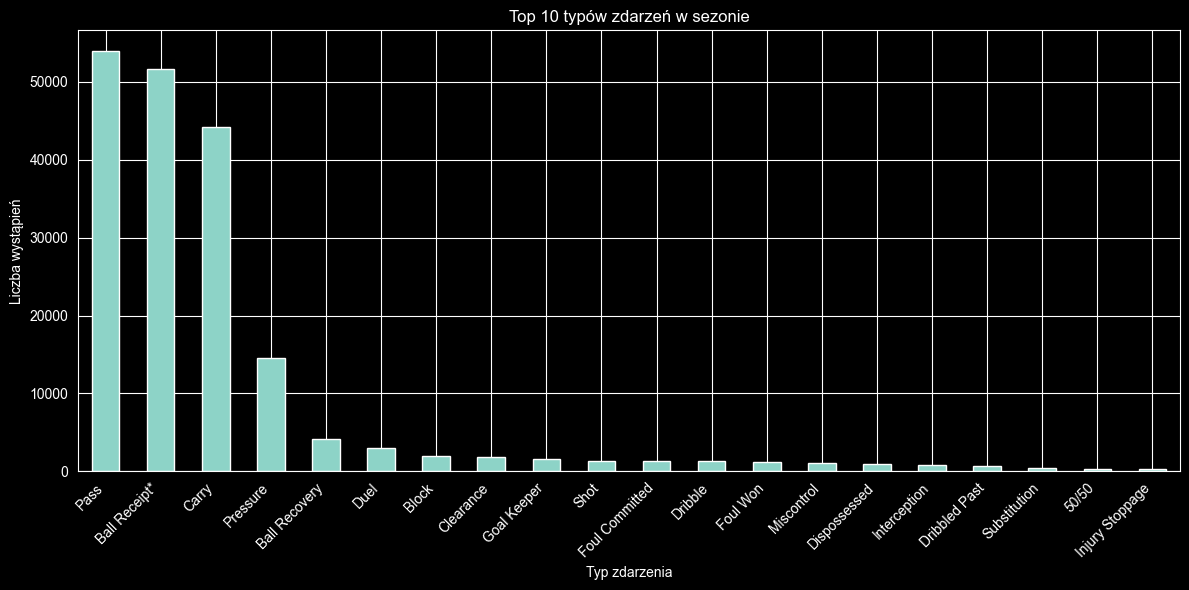

In [9]:
# Wykres topowych typów zdarzeń
plt.figure(figsize=(12, 6))
event_counts.head(20).plot(kind='bar')
plt.xlabel('Typ zdarzenia')
plt.ylabel('Liczba wystąpień')
plt.title('Top 10 typów zdarzeń w sezonie')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Analiza ilości posiadań piłki

In [10]:
def analyze_possessions(events_df: pd.DataFrame) -> pd.DataFrame:
    return events_df.groupby('possession').agg(
        game_id=('game_id', 'first'),
        possession_team=('possession_team_name', 'first'),
        length=('possession', 'size'),
        start_position=('location', 'first'),
        end_position=('location', 'last'),
        period_id=('period_id', 'first'),
        start_timestamp=('timestamp', 'first'),
        end_timestamp=('timestamp', 'last')
    ).reset_index()


In [11]:
from src.data.data_loader import _filter_relevant_events

def analyze_all_matches(matches) -> pd.DataFrame:
    return pd.concat((
        analyze_possessions(_filter_relevant_events(
            events.assign(type=events["type_name"])
            .sort_values("index", kind="mergesort")
            .pipe(lambda df: df[df['team_id'] == df['possession_team_id']])
        ))
        for _, events in matches
    ), ignore_index=True)


In [12]:
possessions_df = analyze_all_matches(matches)
possessions_df.head(10)

,possession,game_id,possession_team,length,start_position,end_position,period_id,start_timestamp,end_timestamp
0,2,3942819,England,8,"[60.0, 40.0]","[81.3, 49.9]",1,0 days 00:00:00.355000,0 days 00:00:14.937000
1,3,3942819,Netherlands,3,"[50.0, 29.3]","[50.5, 29.3]",1,0 days 00:00:16.384000,0 days 00:00:16.744000
2,4,3942819,Netherlands,35,"[50.1, 16.3]","[83.5, 75.9]",1,0 days 00:00:23.802000,0 days 00:01:02.251000
3,5,3942819,England,86,"[36.4, 4.2]","[70.7, 24.3]",1,0 days 00:01:20.961000,0 days 00:02:42.372000
4,6,3942819,England,13,"[63.7, 17.9]","[74.2, 28.6]",1,0 days 00:03:05.757000,0 days 00:03:16.327000
5,7,3942819,Netherlands,24,"[45.9, 51.5]","[96.6, 48.6]",1,0 days 00:03:16.327000,0 days 00:03:37.728000
6,8,3942819,England,31,"[8.2, 33.1]","[111.5, 5.3]",1,0 days 00:03:37.728000,0 days 00:04:26.933000
7,9,3942819,Netherlands,37,"[13.6, 62.5]","[57.1, 6.7]",1,0 days 00:04:45.317000,0 days 00:05:33.191000
8,10,3942819,England,38,"[63.0, 73.4]","[77.5, 32.9]",1,0 days 00:05:33.191000,0 days 00:06:07.448000
9,11,3942819,Netherlands,26,"[9.4, 60.2]","[99.6, 51.2]",1,0 days 00:06:07.448000,0 days 00:06:41.445000


In [13]:
def calculate_possession_statistics(possessions_df: pd.DataFrame) -> dict:
    mode_result = possessions_df['length'].mode()
    return {
        'mean_length': possessions_df['length'].mean(),
        'median_length': possessions_df['length'].median(),
        'mode_length': mode_result[0] if not mode_result.empty else None,
        'std_length': possessions_df['length'].std(),
        'min_length': possessions_df['length'].min(),
        'max_length': possessions_df['length'].max(),
        'q25': possessions_df['length'].quantile(0.25),
        'q75': possessions_df['length'].quantile(0.75),
        'total_possessions': len(possessions_df)
    }


In [14]:
stats = calculate_possession_statistics(possessions_df)
for key, value in stats.items():
    if isinstance(value, (int, float)):
        print(f"  {key}: {value:.2f}")
    else:
        print(f"  {key}: {value}")


  mean_length: 19.87
  median_length: 13.00
  mode_length: 3
  std_length: 20.94
  min_length: 1
  max_length: 194
  q25: 6.00
  q75: 26.00
  total_possessions: 7920.00


In [15]:
def calculate_possession_percentiles(possessions_df: pd.DataFrame) -> dict:
    """Calculate what percentage of possessions have >= specific minimum length"""
    percentiles = {}
    max_length = int(possessions_df['length'].max())
    for length in range(2, min(15, max_length + 1)):
        pct = (possessions_df['length'] >= length).sum() / len(possessions_df) * 100
        percentiles[length] = pct
    return percentiles


In [16]:
percentiles = calculate_possession_percentiles(possessions_df)
for length, pct in percentiles.items():
    print(f"  Co najmniej {length} zdarzeń: {pct:.1f}%")


  Co najmniej 2 zdarzeń: 95.6%
  Co najmniej 3 zdarzeń: 92.5%
  Co najmniej 4 zdarzeń: 86.3%
  Co najmniej 5 zdarzeń: 80.3%
  Co najmniej 6 zdarzeń: 76.7%
  Co najmniej 7 zdarzeń: 72.4%
  Co najmniej 8 zdarzeń: 67.9%
  Co najmniej 9 zdarzeń: 64.3%
  Co najmniej 10 zdarzeń: 60.4%
  Co najmniej 11 zdarzeń: 56.2%
  Co najmniej 12 zdarzeń: 52.8%
  Co najmniej 13 zdarzeń: 50.1%
  Co najmniej 14 zdarzeń: 47.3%


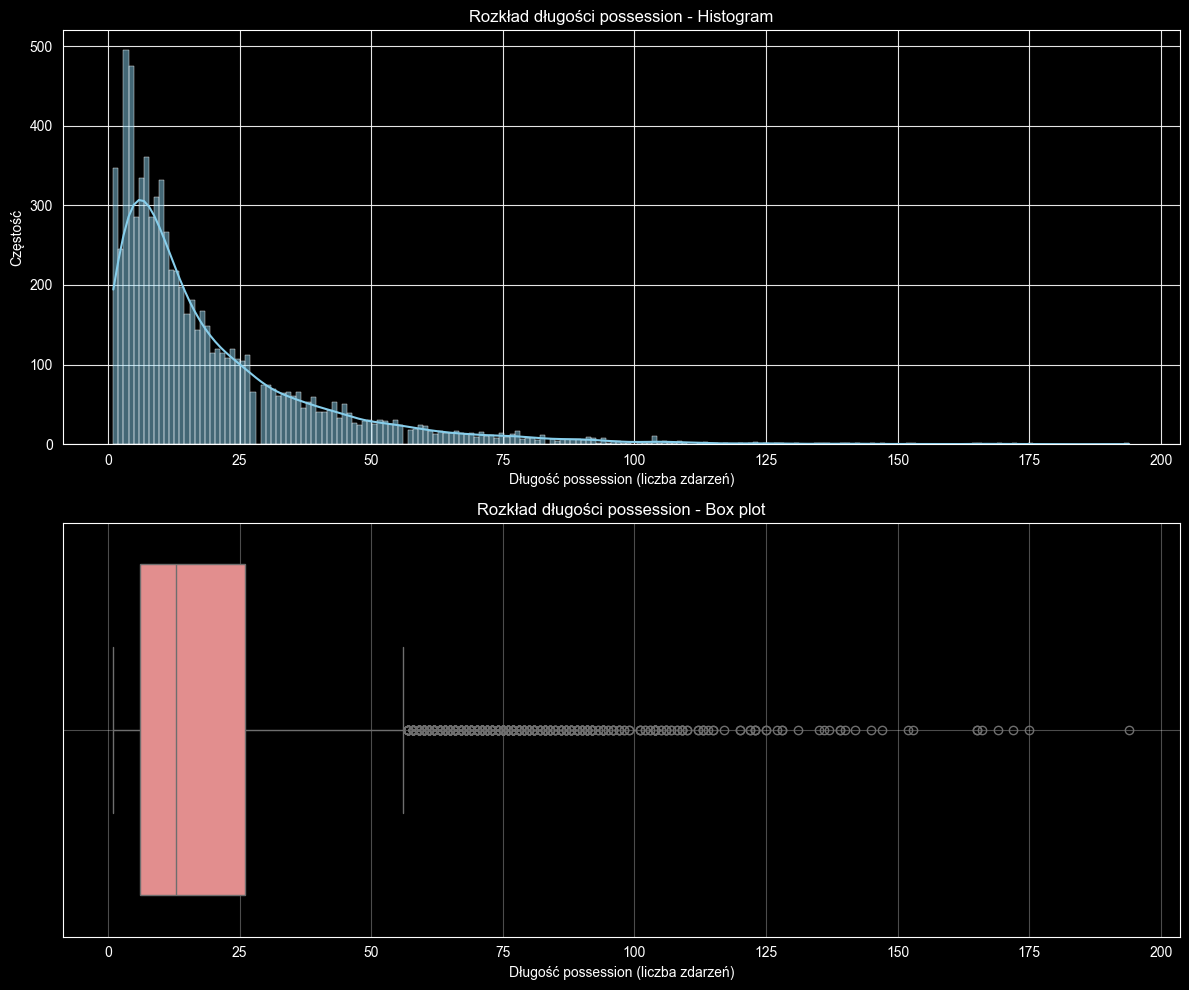

In [17]:
"""Create a histogram and KDE plot for possession length distribution"""
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Histogram with KDE
sns.histplot(data=possessions_df, x='length', kde=True, bins=200, ax=axes[0], color='skyblue')
axes[0].set_xlabel('Długość possession (liczba zdarzeń)')
axes[0].set_ylabel('Częstość')
axes[0].set_title(f'Rozkład długości possession - Histogram')
axes[0].grid(alpha=0.9)

# Box plot
sns.boxplot(data=possessions_df, x='length', ax=axes[1], color='lightcoral')
axes[1].set_xlabel('Długość possession (liczba zdarzeń)')
axes[1].set_title(f'Rozkład długości possession - Box plot')
axes[1].grid(alpha=0.3)

plt.tight_layout()


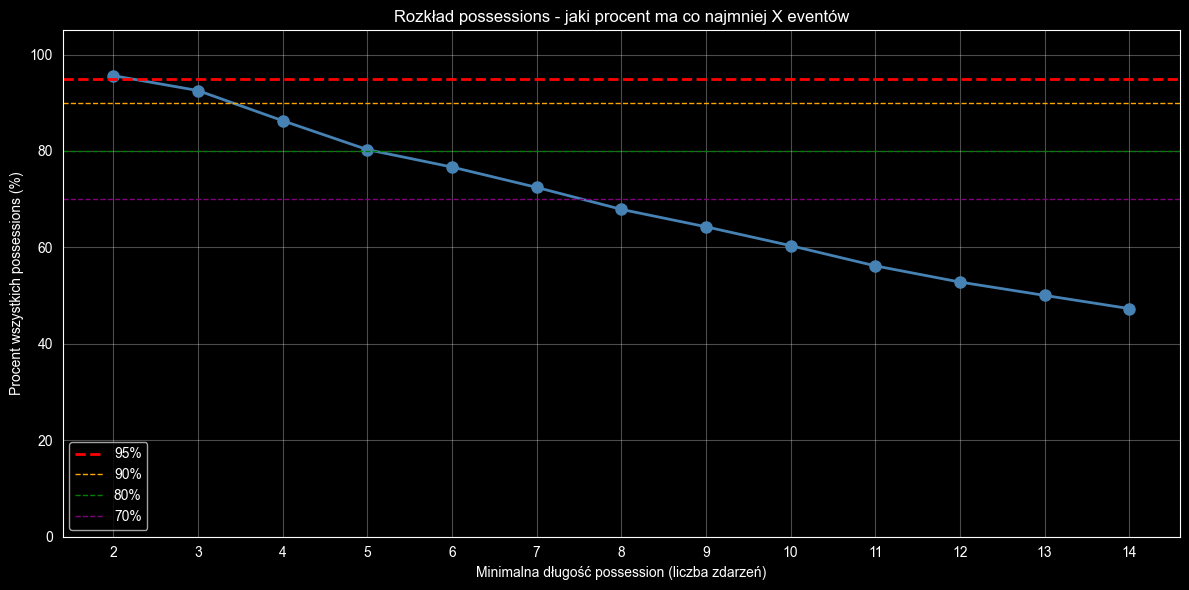

In [18]:
"""Create a cumulative distribution plot showing minimum possession lengths"""
percentiles = calculate_possession_percentiles(possessions_df)
lengths = list(percentiles.keys())
percentages = list(percentiles.values())

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(lengths, percentages, marker='o', linewidth=2, markersize=8, color='steelblue')
ax.axhline(y=95, color='r', linestyle='--', label='95%', linewidth=2)
ax.axhline(y=90, color='orange', linestyle='--', label='90%', linewidth=1)
ax.axhline(y=80, color='green', linestyle='--', label='80%', linewidth=1)
ax.axhline(y=70, color='purple', linestyle='--', label='70%', linewidth=1)
ax.set_xlabel('Minimalna długość possession (liczba zdarzeń)')
ax.set_ylabel('Procent wszystkich possessions (%)')
ax.set_title('Rozkład possessions - jaki procent ma co najmniej X eventów')
ax.set_xticks(lengths)
ax.grid(alpha=0.3)
ax.legend()
ax.set_ylim((0, 105))
plt.tight_layout()


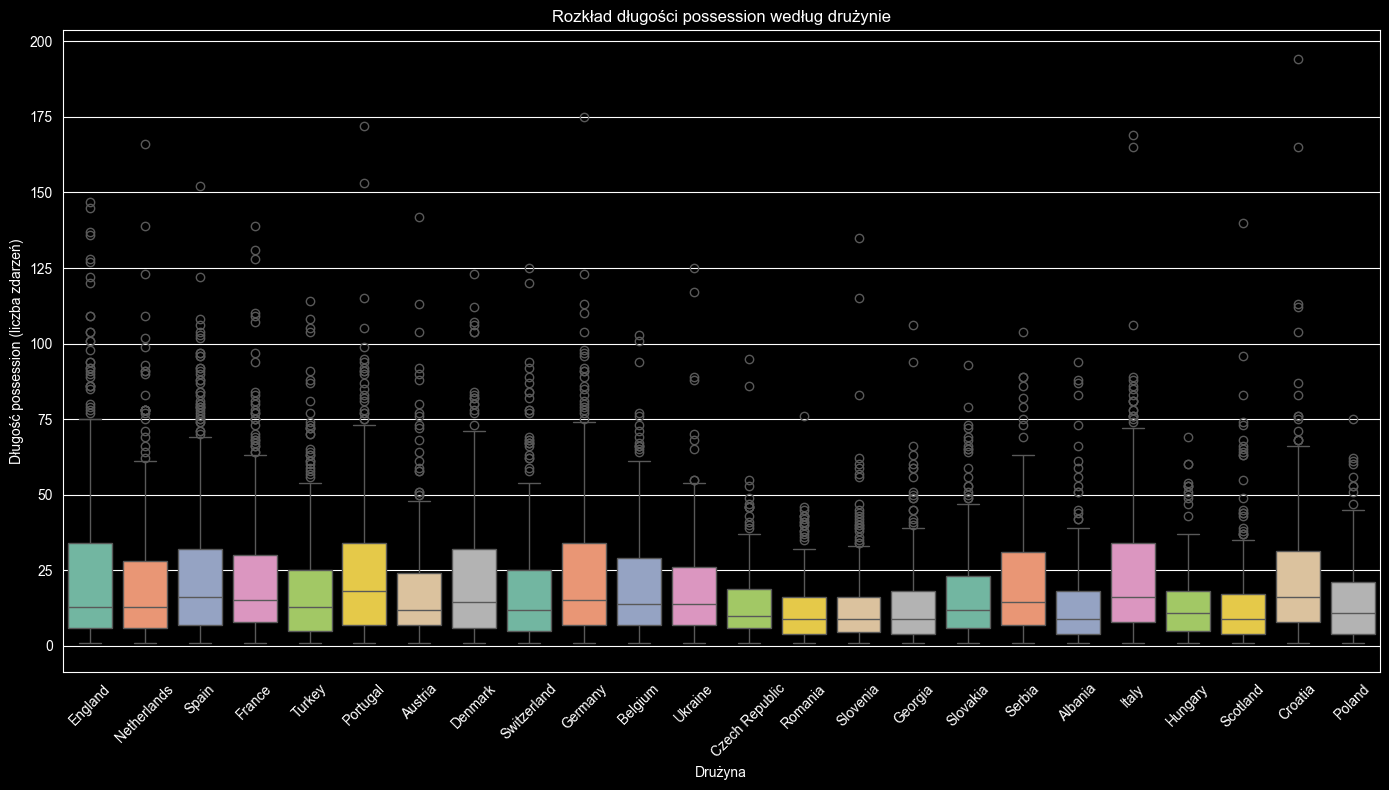

In [19]:
fig, ax = plt.subplots(figsize=(14, 8))

sns.boxplot(data=possessions_df, x='possession_team', y='length', hue='possession_team', ax=ax, palette='Set2', legend=False)
ax.set_xlabel('Drużyna')
ax.set_ylabel('Długość possession (liczba zdarzeń)')
ax.set_title('Rozkład długości possession według drużynie')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()


## Analiza wygenerowanych danych treningowych


### Przetworzenie danych do sekwencji za pomocą SequencePreprocessor


In [20]:
from src.ml.preprocessing.sequence import SequencePreprocessor, PreprocessingMode
from src.ml.xthreat import get_default_xt_model
import config

# Initialize preprocessor
preprocessor = SequencePreprocessor(
    sequence_length=config.SEQUENCE_LENGTH,
    minimum_sequence_length=config.MINIMUM_SEQUENCE_LENGTH,
    xt_model=get_default_xt_model("../../models/xt_models/default_xt_model.json")
)

print(f"Preprocessor Configuration:")
print(f"  - Sequence Length: {config.SEQUENCE_LENGTH}")
print(f"  - Minimum Sequence Length: {config.MINIMUM_SEQUENCE_LENGTH}")
print(f"  - Total matches: {len(matches)}")


Preprocessor Configuration:
  - Sequence Length: 6
  - Minimum Sequence Length: 3
  - Total matches: 51


### Generowanie danych TRAINING mode


In [21]:
X_train, y_train, p_train, m_train = preprocessor.process_matches(matches, mode=PreprocessingMode.TRAINING)


→Processing match 3942819: 3485 events (mode: training)
 → Generated 1657 sequences, 1657 labels for match 3942819
→Processing match 3943043: 3312 events (mode: training)
 → Generated 1301 sequences, 1301 labels for match 3943043
→Processing match 3942752: 3328 events (mode: training)
 → Generated 1289 sequences, 1289 labels for match 3942752
→Processing match 3942382: 3415 events (mode: training)
 → Generated 1468 sequences, 1468 labels for match 3942382
→Processing match 3942349: 5190 events (mode: training)
 → Generated 2424 sequences, 2424 labels for match 3942349
→Processing match 3930180: 3198 events (mode: training)
 → Generated 1207 sequences, 1207 labels for match 3930180
→Processing match 3930171: 3881 events (mode: training)
 → Generated 1713 sequences, 1713 labels for match 3930171
→Processing match 3942227: 4882 events (mode: training)
 → Generated 2236 sequences, 2236 labels for match 3942227
→Processing match 3942226: 4463 events (mode: training)
 → Generated 1768 sequen

### Generowanie danych VALIDATION mode


In [22]:
X_val, y_val, p_val, m_val = preprocessor.process_matches(matches, mode=PreprocessingMode.VALIDATION)


→Processing match 3942819: 3485 events (mode: validation)
 → Generated 97 sequences, 97 labels for match 3942819
→Processing match 3943043: 3312 events (mode: validation)
 → Generated 124 sequences, 124 labels for match 3943043
→Processing match 3942752: 3328 events (mode: validation)
 → Generated 132 sequences, 132 labels for match 3942752
→Processing match 3942382: 3415 events (mode: validation)
 → Generated 105 sequences, 105 labels for match 3942382
→Processing match 3942349: 5190 events (mode: validation)
 → Generated 158 sequences, 158 labels for match 3942349
→Processing match 3930180: 3198 events (mode: validation)
 → Generated 141 sequences, 141 labels for match 3930180
→Processing match 3930171: 3881 events (mode: validation)
 → Generated 121 sequences, 121 labels for match 3930171
→Processing match 3942227: 4882 events (mode: validation)
 → Generated 134 sequences, 134 labels for match 3942227
→Processing match 3942226: 4463 events (mode: validation)
 → Generated 187 sequenc

### Porównanie statystyk - TRAINING vs VALIDATION


In [24]:
import numpy as np

comparison_data = {
    'Metryka': [
        'Liczba sekwencji',
        'Długość sekwencji (kształt)',
        'Liczba unikalnych meczów',
        'Min wartość etykiety',
        'Max wartość etykiety',
        'Średnia wartość etykiety',
        'Mediana wartości etykiety',
        'Std wartości etykiety'
    ],
    'TRAINING Mode': [
        len(X_train),
        X_train.shape,
        len(np.unique(m_train)),
        y_train.min(),
        y_train.max(),
        y_train.mean(),
        np.median(y_train),
        y_train.std()
    ],
    'VALIDATION Mode': [
        len(X_val),
        X_val.shape,
        len(np.unique(m_val)),
        y_val.min(),
        y_val.max(),
        y_val.mean(),
        np.median(y_val),
        y_val.std()
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("PORÓWNANIE DANYCH TRAINING vs VALIDATION")
print("="*80)
print(comparison_df.to_string(index=False))



PORÓWNANIE DANYCH TRAINING vs VALIDATION
                    Metryka  TRAINING Mode VALIDATION Mode
           Liczba sekwencji          77422            6823
Długość sekwencji (kształt) (77422, 6, 46)   (6823, 6, 46)
   Liczba unikalnych meczów             51              51
       Min wartość etykiety       0.006383        0.006383
       Max wartość etykiety       1.239184        1.239184
   Średnia wartość etykiety       0.028403         0.05819
  Mediana wartości etykiety       0.017451        0.027563
      Std wartości etykiety       0.043614        0.082464


### Rozkład etykiet w trybie TRAINING


/var/folders/vd/ld_f127d3sb255vmfwhgmc140000gn/T/ipykernel_61698/819571601.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([y_train], labels=['TRAINING'])


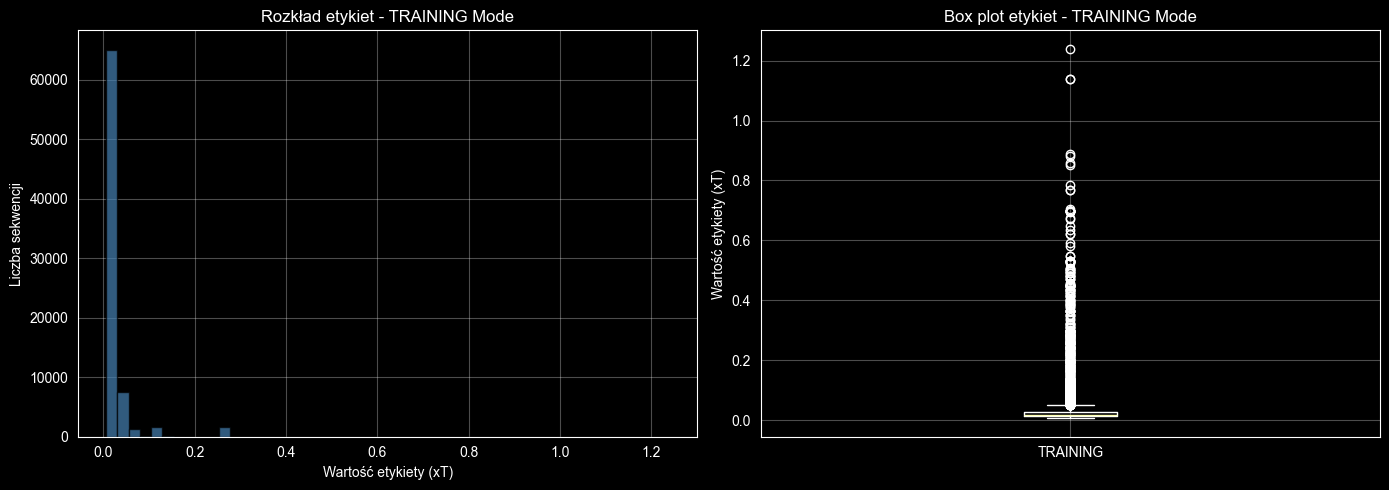

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(y_train, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Wartość etykiety (xT)')
axes[0].set_ylabel('Liczba sekwencji')
axes[0].set_title('Rozkład etykiet - TRAINING Mode')
axes[0].grid(alpha=0.3)

# Box plot
axes[1].boxplot([y_train], labels=['TRAINING'])
axes[1].set_ylabel('Wartość etykiety (xT)')
axes[1].set_title('Box plot etykiet - TRAINING Mode')
axes[1].grid(alpha=0.3)

plt.tight_layout()


### Rozkład etykiet w trybie VALIDATION


/var/folders/vd/ld_f127d3sb255vmfwhgmc140000gn/T/ipykernel_61698/4118661113.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([y_val], labels=['VALIDATION'])


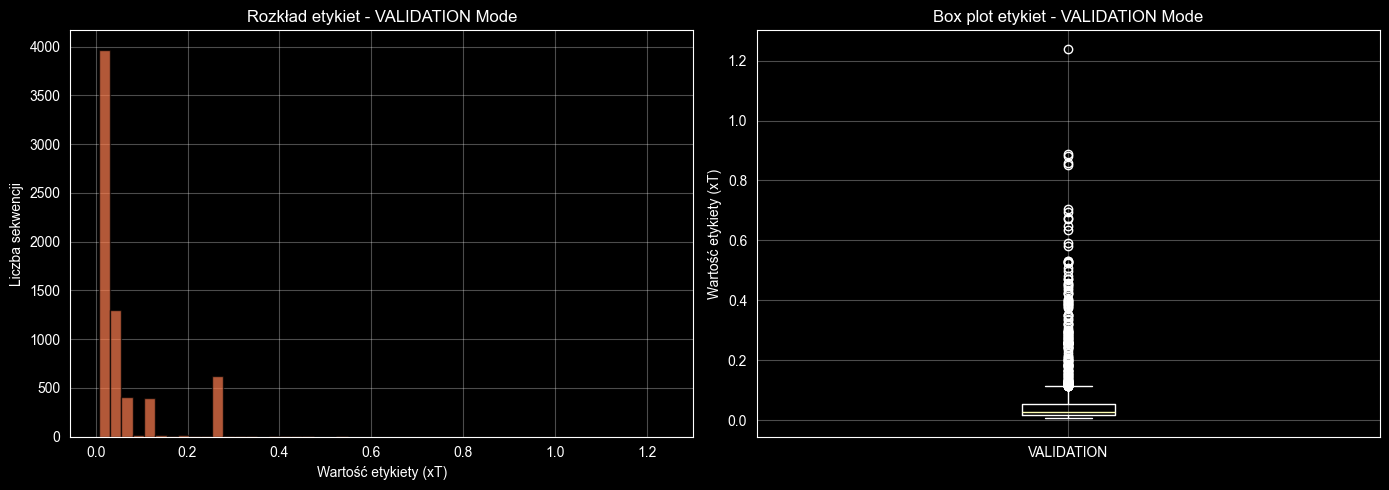

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(y_val, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Wartość etykiety (xT)')
axes[0].set_ylabel('Liczba sekwencji')
axes[0].set_title('Rozkład etykiet - VALIDATION Mode')
axes[0].grid(alpha=0.3)

# Box plot
axes[1].boxplot([y_val], labels=['VALIDATION'])
axes[1].set_ylabel('Wartość etykiety (xT)')
axes[1].set_title('Box plot etykiet - VALIDATION Mode')
axes[1].grid(alpha=0.3)

plt.tight_layout()


### Porównanie rozkładów obok siebie


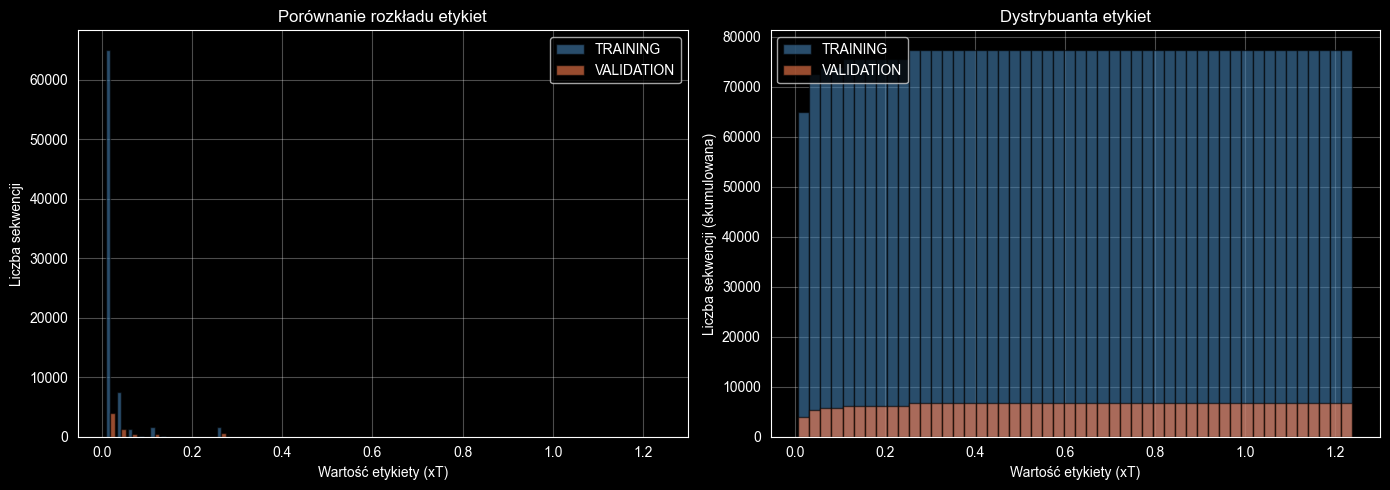

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist([y_train, y_val], bins=50, label=['TRAINING', 'VALIDATION'], color=['steelblue', 'coral'], alpha=0.6, edgecolor='black')
axes[0].set_xlabel('Wartość etykiety (xT)')
axes[0].set_ylabel('Liczba sekwencji')
axes[0].set_title('Porównanie rozkładu etykiet')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Cumulative distribution
axes[1].hist(y_train, bins=50, cumulative=True, label='TRAINING', alpha=0.6, color='steelblue', edgecolor='black')
axes[1].hist(y_val, bins=50, cumulative=True, label='VALIDATION', alpha=0.6, color='coral', edgecolor='black')
axes[1].set_xlabel('Wartość etykiety (xT)')
axes[1].set_ylabel('Liczba sekwencji (skumulowana)')
axes[1].set_title('Dystrybuanta etykiet')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()


### Liczba sekwencji na mecz


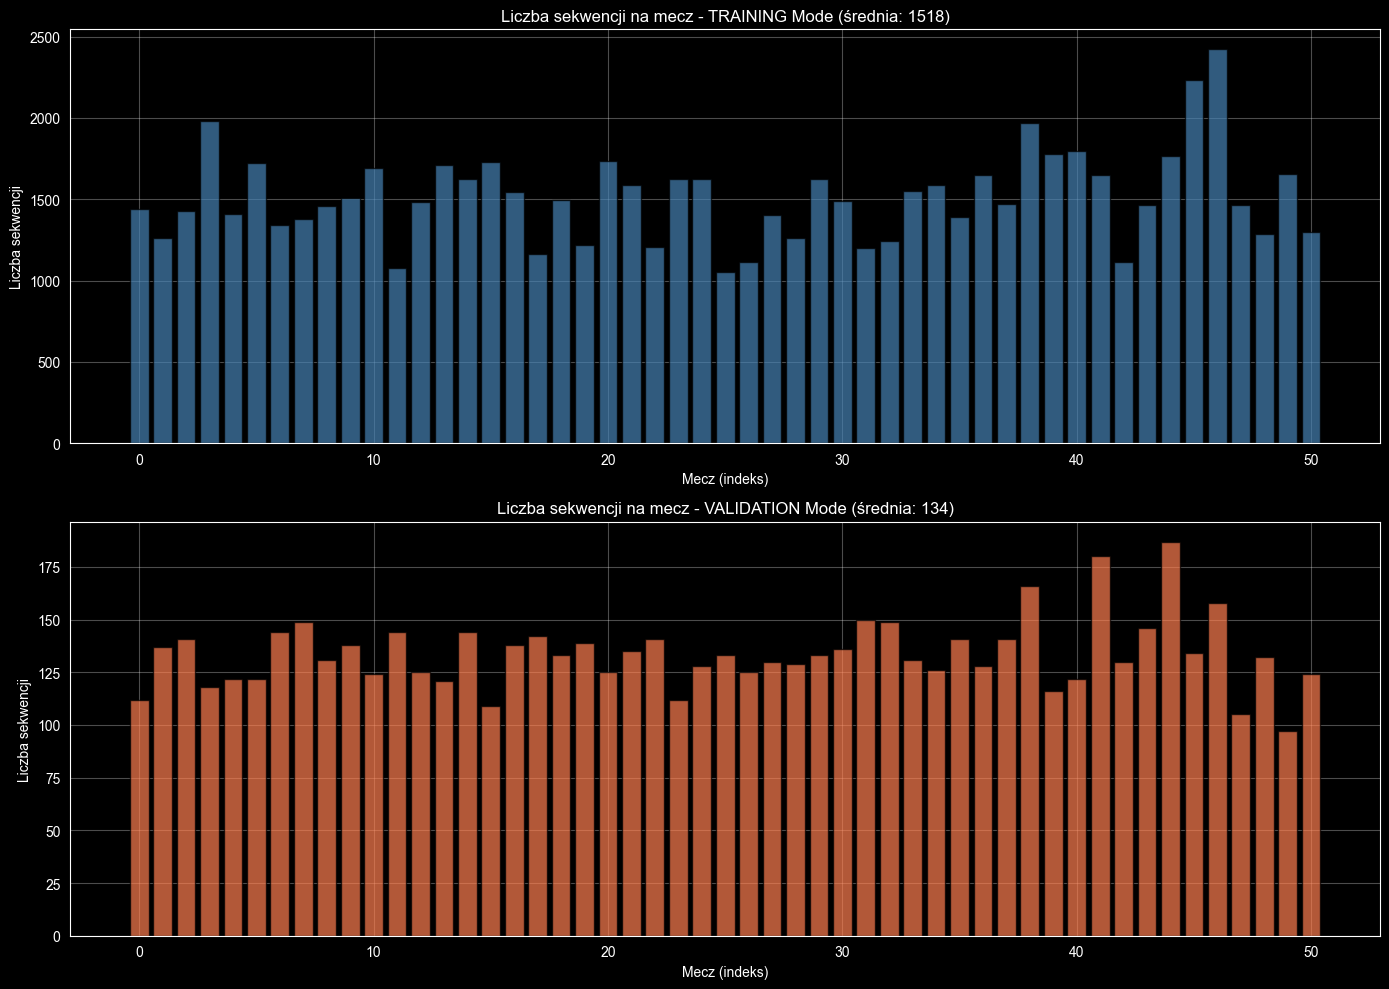

In [28]:
train_sequences_per_match = pd.Series(m_train).value_counts().sort_index()
val_sequences_per_match = pd.Series(m_val).value_counts().sort_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Training
axes[0].bar(range(len(train_sequences_per_match)), train_sequences_per_match.values, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Mecz (indeks)')
axes[0].set_ylabel('Liczba sekwencji')
axes[0].set_title(f'Liczba sekwencji na mecz - TRAINING Mode (średnia: {train_sequences_per_match.mean():.0f})')
axes[0].grid(alpha=0.3)

# Validation
axes[1].bar(range(len(val_sequences_per_match)), val_sequences_per_match.values, color='coral', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Mecz (indeks)')
axes[1].set_ylabel('Liczba sekwencji')
axes[1].set_title(f'Liczba sekwencji na mecz - VALIDATION Mode (średnia: {val_sequences_per_match.mean():.0f})')
axes[1].grid(alpha=0.3)

plt.tight_layout()


### Statystyki dla każdego trybu


In [29]:
print("\n" + "="*80)
print("SZCZEGÓŁOWE STATYSTYKI")
print("="*80)

print("\nTRAINING Mode:")
print(f"  - Liczba sekwencji: {len(X_train):,}")
print(f"  - Liczba meczów: {len(np.unique(m_train))}")
print(f"  - Średnia sekwencji na mecz: {len(X_train) / len(np.unique(m_train)):.0f}")
print(f"  - Min/Max/Avg etykiet: {y_train.min():.4f} / {y_train.max():.4f} / {y_train.mean():.4f}")
print(f"  - Rozmiar danych X: {X_train.nbytes / (1024**2):.2f} MB")

print("\nVALIDATION Mode:")
print(f"  - Liczba sekwencji: {len(X_val):,}")
print(f"  - Liczba meczów: {len(np.unique(m_val))}")
print(f"  - Średnia sekwencji na mecz: {len(X_val) / len(np.unique(m_val)):.0f}")
print(f"  - Min/Max/Avg etykiet: {y_val.min():.4f} / {y_val.max():.4f} / {y_val.mean():.4f}")
print(f"  - Rozmiar danych X: {X_val.nbytes / (1024**2):.2f} MB")

print("\nRazem:")
print(f"  - Razem sekwencji: {len(X_train) + len(X_val):,}")
print(f"  - Stosunek TRAINING/VALIDATION: {len(X_train) / len(X_val):.2f}")





SZCZEGÓŁOWE STATYSTYKI

TRAINING Mode:
  - Liczba sekwencji: 77,422
  - Liczba meczów: 51
  - Średnia sekwencji na mecz: 1518
  - Min/Max/Avg etykiet: 0.0064 / 1.2392 / 0.0284
  - Rozmiar danych X: 81.51 MB

VALIDATION Mode:
  - Liczba sekwencji: 6,823
  - Liczba meczów: 51
  - Średnia sekwencji na mecz: 134
  - Min/Max/Avg etykiet: 0.0064 / 1.2392 / 0.0582
  - Rozmiar danych X: 7.18 MB

Razem:
  - Razem sekwencji: 84,245
  - Stosunek TRAINING/VALIDATION: 11.35
